In [8]:
import json, time, warnings, requests
from pathlib import Path
from datetime import datetime, timedelta
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
 
warnings.filterwarnings('ignore')
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
 
# =============================================================================
# LOCATION CONFIG SWITCH
# Set LOCATION_MODE to one of:
#   'pune'    — single location, Pune Maharashtra
#   'india'   — 8 representative Indian agricultural locations
#   'custom'  — use your own GPS coordinates below
# =============================================================================
LOCATION_MODE = 'pune'    # <-- CHANGE THIS to switch locations
 
CUSTOM_LAT  = 18.5204     # used only when LOCATION_MODE = 'custom'
CUSTOM_LON  = 73.8567
CUSTOM_NAME = 'Pune'
 
# Predefined location library
LOCATION_LIBRARY = {
    'pune'       : {'lat': 18.5204, 'lon': 73.8567,  'name': 'Pune, Maharashtra'},
    'nashik'     : {'lat': 20.0059, 'lon': 73.7898,  'name': 'Nashik, Maharashtra'},
    'nagpur'     : {'lat': 21.1458, 'lon': 79.0882,  'name': 'Nagpur, Maharashtra'},
    'delhi'      : {'lat': 28.6139, 'lon': 77.2090,  'name': 'Delhi'},
    'bangalore'  : {'lat': 12.9716, 'lon': 77.5946,  'name': 'Bangalore, Karnataka'},
    'hyderabad'  : {'lat': 17.3850, 'lon': 78.4867,  'name': 'Hyderabad, Telangana'},
    'kolkata'    : {'lat': 22.5726, 'lon': 88.3639,  'name': 'Kolkata, West Bengal'},
    'ludhiana'   : {'lat': 30.9010, 'lon': 75.8573,  'name': 'Ludhiana, Punjab'},
}
 
# Build active location list
if LOCATION_MODE == 'pune':
    ACTIVE_LOCATIONS = [LOCATION_LIBRARY['pune']]
elif LOCATION_MODE == 'india':
    ACTIVE_LOCATIONS = list(LOCATION_LIBRARY.values())
elif LOCATION_MODE == 'custom':
    ACTIVE_LOCATIONS = [{'lat': CUSTOM_LAT, 'lon': CUSTOM_LON, 'name': CUSTOM_NAME}]
else:
    raise ValueError(f"Unknown LOCATION_MODE: {LOCATION_MODE}")
 
print(f"Mode     : {LOCATION_MODE}")
print(f"Locations: {[l['name'] for l in ACTIVE_LOCATIONS]}")


Device : cuda
Mode     : pune
Locations: ['Pune, Maharashtra']


In [9]:
DISEASE_THRESHOLDS = {
    # Apple
    'Apple___Apple_scab'              : (6,  24, 70, 0.5),
    'Apple___Black_rot'               : (18, 29, 60, 0.3),
    'Apple___Cedar_apple_rust'        : (8,  20, 65, 0.5),
    'Apple___healthy'                 : None,
 
    # Blueberry
    'Blueberry___healthy'             : None,
 
    # Cherry
    'Cherry_(including_sour)___Powdery_mildew' : (15, 28, 50, 0.0),
    'Cherry_(including_sour)___healthy'        : None,
 
    # Corn
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot' : (25, 35, 90, 1.0),
    'Corn_(maize)___Common_rust_'              : (16, 23, 95, 0.5),
    'Corn_(maize)___Northern_Leaf_Blight'      : (18, 27, 90, 1.0),
    'Corn_(maize)___healthy'                   : None,
 
    # Grape
    'Grape___Black_rot'                        : (15, 29, 80, 0.5),
    'Grape___Esca_(Black_Measles)'             : (20, 30, 70, 0.3),
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': (20, 30, 85, 1.0),
    'Grape___healthy'                          : None,
 
    # Orange
    'Orange___Haunglongbing_(Citrus_greening)' : (25, 35, 60, 0.0),
 
    # Peach
    'Peach___Bacterial_spot'                   : (24, 30, 80, 1.0),
    'Peach___healthy'                          : None,
 
    # Pepper
    'Pepper,_bell___Bacterial_spot'            : (24, 30, 90, 1.0),
    'Pepper,_bell___healthy'                   : None,
 
    # Potato
    'Potato___Early_blight'                    : (24, 29, 90, 0.5),
    'Potato___Late_blight'                     : (10, 24, 90, 1.0),   # key disease
    'Potato___healthy'                         : None,
 
    # Raspberry
    'Raspberry___healthy'                      : None,
 
    # Soybean
    'Soybean___healthy'                        : None,
 
    # Squash
    'Squash___Powdery_mildew'                  : (20, 30, 50, 0.0),
 
    # Strawberry
    'Strawberry___Leaf_scorch'                 : (20, 30, 70, 0.3),
    'Strawberry___healthy'                     : None,
 
    # Tomato
    'Tomato___Bacterial_spot'                  : (24, 30, 90, 1.0),
    'Tomato___Early_blight'                    : (24, 29, 90, 0.5),
    'Tomato___Late_blight'                     : (10, 24, 90, 1.0),
    'Tomato___Leaf_Mold'                       : (22, 25, 85, 0.0),
    'Tomato___Septoria_leaf_spot'              : (20, 25, 92, 1.0),
    'Tomato___Spider_mites Two-spotted_spider_mite' : (27, 38, 30, 0.0),
    'Tomato___Target_Spot'                     : (20, 30, 80, 0.5),
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus'   : (21, 32, 60, 0.0),
    'Tomato___Tomato_mosaic_virus'             : (22, 28, 60, 0.0),
    'Tomato___healthy'                         : None,
}
 
# Only diseases (not healthy classes) get a risk score
DISEASE_CLASSES = [k for k, v in DISEASE_THRESHOLDS.items() if v is not None]
print(f"Disease classes with thresholds : {len(DISEASE_CLASSES)}")
print(f"Healthy classes (no risk score) : "
      f"{len(DISEASE_THRESHOLDS) - len(DISEASE_CLASSES)}")

Disease classes with thresholds : 26
Healthy classes (no risk score) : 12


In [12]:
# def fetch_openmeteo_historical(lat, lon, start_date, end_date):
#     """
#     Uses open-meteo.com (main domain) instead of archive subdomain.
#     Falls back to climate API if archive is blocked.
#     """
#     # Try main API first
#     urls_to_try = [
#         "https://archive.open-meteo.com/v1/archive",
#         "https://historical-forecast-api.open-meteo.com/v1/forecast",
#         "https://api.open-meteo.com/v1/forecast",
#     ]

#     params = {
#         'latitude'              : lat,
#         'longitude'             : lon,
#         'start_date'            : start_date,
#         'end_date'              : end_date,
#         'daily'                 : [
#             'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
#             'precipitation_sum',
#             'relative_humidity_2m_max', 'relative_humidity_2m_min',
#             'windspeed_10m_max',
#             'shortwave_radiation_sum',
#             'et0_fao_evapotranspiration',
#         ],
#         'timezone'              : 'Asia/Kolkata',
#         'wind_speed_unit'       : 'kmh',
#     }

#     for url in urls_to_try:
#         try:
#             print(f"  Trying: {url}")
#             resp = requests.get(url, params=params, timeout=30, verify=False)
#             resp.raise_for_status()
#             data = resp.json()
#             if 'daily' in data:
#                 df = pd.DataFrame(data['daily'])
#                 df['time'] = pd.to_datetime(df['time'])
#                 df.set_index('time', inplace=True)
#                 df.columns = [
#                     'temp_max', 'temp_min', 'temp_mean',
#                     'precipitation',
#                     'humidity_max', 'humidity_min',
#                     'windspeed',
#                     'solar_radiation',
#                     'et0'
#                 ]
#                 print(f"  Success from: {url}")
#                 return df
#         except Exception as e:
#             print(f"  Failed: {e}")
#             continue

#     raise ConnectionError("All Open-Meteo endpoints failed. Use CSV fallback below.")
def fetch_nasa_power(lat, lon, start_date, end_date):
    """
    NASA POWER API — completely different domain, rarely blocked.
    Free, no API key, global coverage.
    """
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        'parameters' : 'T2M_MAX,T2M_MIN,T2M,PRECTOTCORR,RH2M,WS10M,ALLSKY_SFC_SW_DWN',
        'community'  : 'AG',
        'longitude'  : lon,
        'latitude'   : lat,
        'start'      : start_date.replace('-', ''),   # NASA uses YYYYMMDD format
        'end'        : end_date.replace('-', ''),
        'format'     : 'JSON',
    }

    print(f"  Fetching from NASA POWER API...")
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    props = data['properties']['parameter']

    dates = pd.date_range(start=start_date, end=end_date, freq='D')

    df = pd.DataFrame({
        'temp_max'        : list(props['T2M_MAX'].values()),
        'temp_min'        : list(props['T2M_MIN'].values()),
        'temp_mean'       : list(props['T2M'].values()),
        'precipitation'   : list(props['PRECTOTCORR'].values()),
        'humidity_max'    : list(props['RH2M'].values()),
        'humidity_min'    : list(props['RH2M'].values()),   # NASA gives mean RH only
        'windspeed'       : list(props['WS10M'].values()),
        'solar_radiation' : list(props['ALLSKY_SFC_SW_DWN'].values()),
        'et0'             : list(props['PRECTOTCORR'].values()),  # approximate
    }, index=dates[:len(list(props['T2M'].values()))])

    # NASA uses -999 for missing values
    df.replace(-999.0, np.nan, inplace=True)
    df = df.interpolate()

    print(f"  NASA POWER: {len(df):,} days fetched")
    return df


# Replace the fetch call with NASA
import urllib3
urllib3.disable_warnings()

print(f"Fetching weather for: {ACTIVE_LOCATIONS[0]['name']}")
sample_df = fetch_nasa_power(
    ACTIVE_LOCATIONS[0]['lat'],
    ACTIVE_LOCATIONS[0]['lon'],
    start_date='2015-01-01',
    end_date='2024-12-31'
)
print(sample_df.tail(3))

Fetching weather for: Pune, Maharashtra
  Fetching from NASA POWER API...
  NASA POWER: 3,653 days fetched
            temp_max  temp_min  temp_mean  precipitation  humidity_max  \
2024-12-29     27.52     16.54      21.20           0.28         79.04   
2024-12-30     27.78     15.67      21.06           0.00         71.68   
2024-12-31     28.45     15.13      20.79           0.00         69.96   

            humidity_min  windspeed  solar_radiation   et0  
2024-12-29         79.04       2.94            15.36  0.28  
2024-12-30         71.68       3.03            15.90  0.00  
2024-12-31         69.96       3.39            16.22  0.00  


In [14]:
def engineer_features(df):
    """
    Takes raw weather DataFrame, returns enriched feature DataFrame.
    All features are epidemiologically meaningful — no arbitrary transforms.
    """
    df = df.copy()
 
    # Handle missing values — linear interpolation then forward fill
    # Handle missing values
    df = df.interpolate(method='linear').ffill().bfill()
 
    # --- VPD (Vapour Pressure Deficit) ---
    # SVP = saturated vapour pressure at temp_mean
    # AVP = actual vapour pressure
    # VPD = SVP - AVP  (kPa)
    # High VPD → dry conditions → suppresses fungal disease
    # Low VPD  → humid conditions → promotes fungal disease
    df['svp']          = 0.6108 * np.exp((17.27 * df['temp_mean']) /
                                          (df['temp_mean'] + 237.3))
    df['humidity_mean'] = (df['humidity_max'] + df['humidity_min']) / 2
    df['avp']          = df['svp'] * (df['humidity_mean'] / 100)
    df['vpd']          = (df['svp'] - df['avp']).clip(lower=0)
 
    # --- Temperature features ---
    df['temp_range']   = df['temp_max'] - df['temp_min']   # diurnal range
    df['heat_stress']  = (df['temp_max'] > 35).astype(float)
 
    # --- Precipitation features ---
    df['wet_day']      = (df['precipitation'] > 1.0).astype(float)
    df['wet_days_7d']  = df['wet_day'].rolling(7, min_periods=1).sum()
    df['precip_7d']    = df['precipitation'].rolling(7, min_periods=1).sum()
    df['precip_30d']   = df['precipitation'].rolling(30, min_periods=1).sum()
 
    # --- Humidity features ---
    df['humidity_7d_mean'] = df['humidity_mean'].rolling(7, min_periods=1).mean()
 
    # --- Solar radiation normalised ---
    df['solar_norm']   = df['solar_radiation'] / (df['solar_radiation'].max() + 1e-8)
 
    # --- Season encoding (month as cyclical sin/cos) ---
    month              = df.index.month
    df['month_sin']    = np.sin(2 * np.pi * month / 12)
    df['month_cos']    = np.cos(2 * np.pi * month / 12)
 
    # Drop intermediate columns
    df.drop(columns=['svp', 'avp', 'wet_day'], inplace=True)
 
    return df
 
 
# Apply feature engineering
sample_df = engineer_features(sample_df)
print(f"Features after engineering: {list(sample_df.columns)}")
print(f"Shape: {sample_df.shape}")
print(f"\nSample VPD range: {sample_df['vpd'].min():.2f} – {sample_df['vpd'].max():.2f} kPa")
print(f"Sample humidity mean range: "
      f"{sample_df['humidity_mean'].min():.1f} – {sample_df['humidity_mean'].max():.1f}%")

Features after engineering: ['temp_max', 'temp_min', 'temp_mean', 'precipitation', 'humidity_max', 'humidity_min', 'windspeed', 'solar_radiation', 'et0', 'humidity_mean', 'vpd', 'temp_range', 'heat_stress', 'wet_days_7d', 'precip_7d', 'precip_30d', 'humidity_7d_mean', 'solar_norm', 'month_sin', 'month_cos']
Shape: (3653, 20)

Sample VPD range: 0.10 – 3.79 kPa
Sample humidity mean range: 15.9 – 96.6%


In [15]:
def compute_dcws(df, disease_thresholds):
    """
    Computes Disease Conducive Weather Score for each disease class.
 
    Score = sigmoid blend of:
      - temperature score    : how well temp_mean fits the conducive window
      - humidity score       : whether humidity_mean exceeds threshold
      - precipitation score  : whether daily precipitation exceeds threshold
 
    Returns DataFrame with one column per disease class.
    """
    scores = {}
 
    for disease, thresholds in disease_thresholds.items():
        if thresholds is None:
            # Healthy classes always get score 0
            scores[disease] = np.zeros(len(df))
            continue
 
        t_min, t_max, h_min, p_thresh = thresholds
 
        # Temperature score: 1.0 if within window, decays outside
        t_mid   = (t_min + t_max) / 2
        t_range = (t_max - t_min) / 2
        t_score = np.exp(-0.5 * ((df['temp_mean'] - t_mid) / (t_range + 1e-8)) ** 2)
 
        # Humidity score: sigmoid above threshold
        h_score = 1 / (1 + np.exp(-(df['humidity_mean'] - h_min) / 5))
 
        # Precipitation score
        if p_thresh > 0:
            p_score = (df['precipitation'] >= p_thresh).astype(float)
            # Blend with 7-day wet days for persistence
            p_score = 0.5 * p_score + 0.5 * (df['wet_days_7d'] / 7)
        else:
            # Disease spreads even without rain (e.g. powdery mildew, spider mites)
            p_score = np.ones(len(df))
 
        # Weighted combination
        dcws = 0.4 * t_score + 0.4 * h_score + 0.2 * p_score
        scores[disease] = dcws.values
 
    return pd.DataFrame(scores, index=df.index)
 
 
# Compute DCWS for sample location
dcws_df = compute_dcws(sample_df, DISEASE_THRESHOLDS)
print(f"DCWS shape: {dcws_df.shape}")
print(f"\nMean daily risk by disease (top 10):")
print(dcws_df[DISEASE_CLASSES].mean().sort_values(ascending=False).head(10).round(3))


DCWS shape: (3653, 38)

Mean daily risk by disease (top 10):
Cherry_(including_sour)___Powdery_mildew         0.842
Squash___Powdery_mildew                          0.828
Tomato___Tomato_Yellow_Leaf_Curl_Virus           0.768
Tomato___Spider_mites Two-spotted_spider_mite    0.720
Tomato___Tomato_mosaic_virus                     0.707
Apple___Black_rot                                0.677
Orange___Haunglongbing_(Citrus_greening)         0.653
Grape___Esca_(Black_Measles)                     0.612
Strawberry___Leaf_scorch                         0.612
Grape___Black_rot                                0.581
dtype: float64


In [26]:
def fetch_weather_for_location(location, years_back=10):
    """
    Fetches and engineers weather features for a given location.
    Uses NASA POWER directly — skips Open-Meteo entirely.
    """
    end_date   = '2024-12-31'
    start_date = f'{2024 - years_back + 1}-01-01'

    print(f"  Fetching {years_back} years for {location['name']}...")
    print(f"  Range: {start_date} → {end_date}")

    raw_df = fetch_nasa_power(
        location['lat'],
        location['lon'],
        start_date,
        end_date
    )
    eng_df = engineer_features(raw_df)
    return eng_df


all_weather_dfs = {}
all_dcws_dfs    = {}

for loc in ACTIVE_LOCATIONS:
    key    = loc['name']
    eng_df = fetch_weather_for_location(loc, years_back=10)
    dc_df  = compute_dcws(eng_df, DISEASE_THRESHOLDS)

    all_weather_dfs[key] = eng_df
    all_dcws_dfs[key]    = dc_df
    print(f"  {key}: {len(eng_df)} days engineered + DCWS computed")

# Save processed data for Increment 3
primary_location = ACTIVE_LOCATIONS[0]['name']
all_weather_dfs[primary_location].to_csv('weather_features.csv')
all_dcws_dfs[primary_location].to_csv('dcws_scores.csv')
print(f"\nSaved: weather_features.csv, dcws_scores.csv")

  Fetching 10 years for Pune, Maharashtra...
  Range: 2015-01-01 → 2024-12-31
  Fetching from NASA POWER API...
  NASA POWER: 3,653 days fetched
  Pune, Maharashtra: 3653 days engineered + DCWS computed

Saved: weather_features.csv, dcws_scores.csv


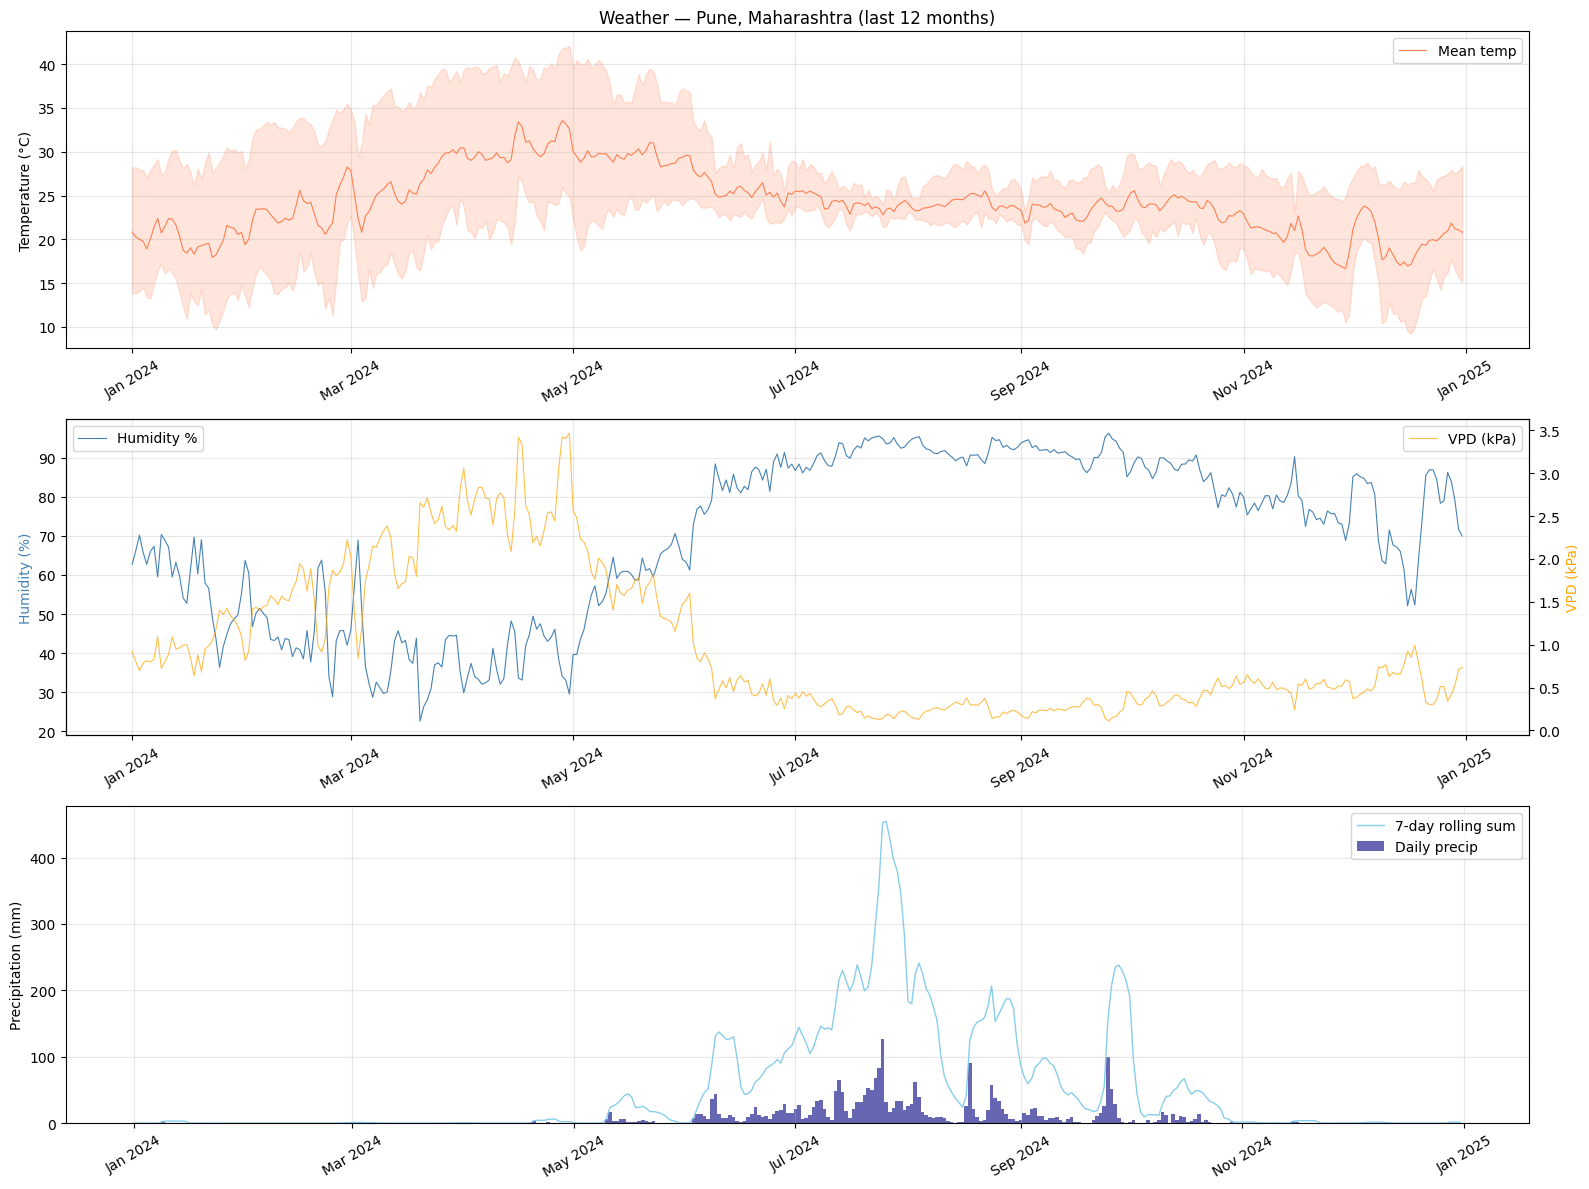

Saved: weather_eda.png


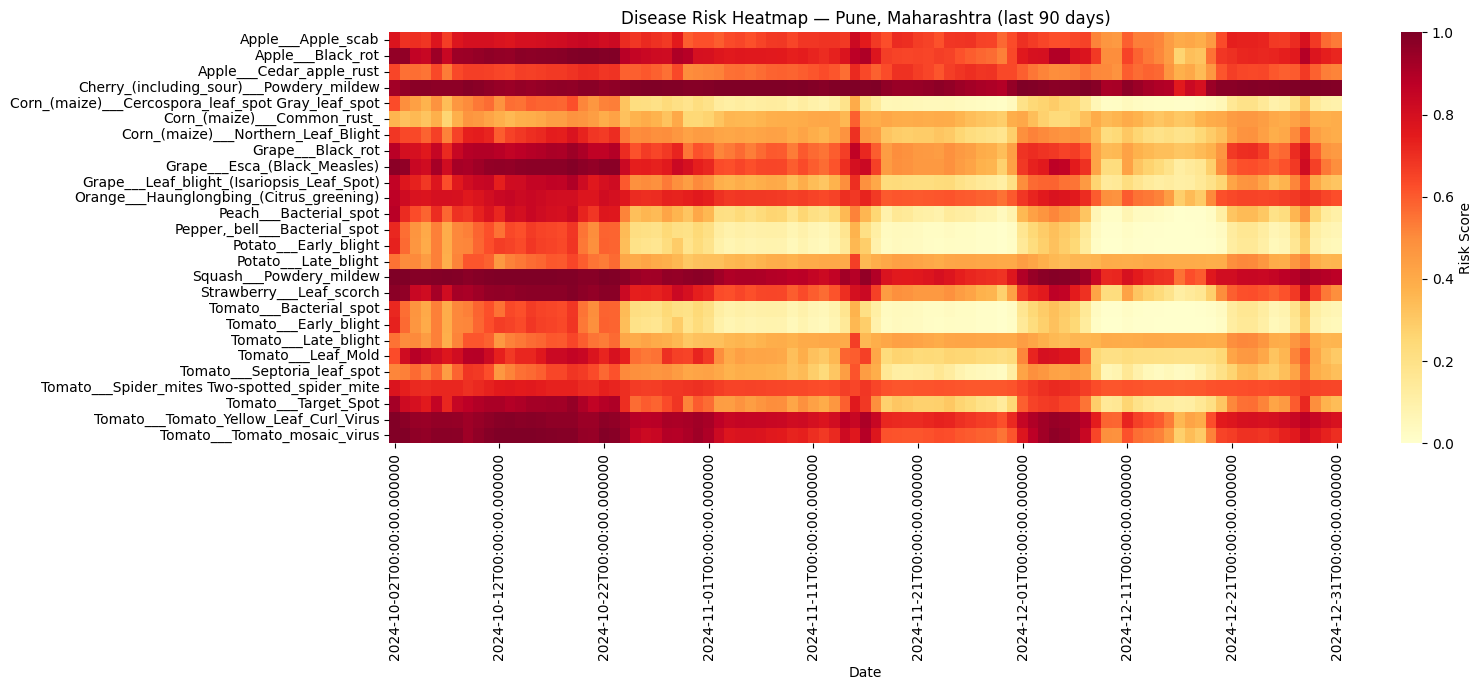

Saved: dcws_heatmap.png


In [27]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
df = all_weather_dfs[primary_location]
df_plot = df.loc[df.index >= df.index.max() - pd.Timedelta(days=365)]
 
# Temperature
axes[0].plot(df_plot.index, df_plot['temp_mean'],
             color='coral', linewidth=0.8, label='Mean temp')
axes[0].fill_between(df_plot.index, df_plot['temp_min'],
                     df_plot['temp_max'], alpha=0.2, color='coral')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Weather — {primary_location} (last 12 months)')
axes[0].legend(); axes[0].grid(alpha=0.3)
 
# Humidity + VPD
ax2 = axes[1].twinx()
axes[1].plot(df_plot.index, df_plot['humidity_mean'],
             color='steelblue', linewidth=0.8, label='Humidity %')
ax2.plot(df_plot.index, df_plot['vpd'],
         color='orange', linewidth=0.8, label='VPD (kPa)', alpha=0.7)
axes[1].set_ylabel('Humidity (%)', color='steelblue')
ax2.set_ylabel('VPD (kPa)', color='orange')
axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')
axes[1].grid(alpha=0.3)
 
# Precipitation
axes[2].bar(df_plot.index, df_plot['precipitation'],
            color='navy', alpha=0.6, width=1, label='Daily precip')
axes[2].plot(df_plot.index, df_plot['precip_7d'],
             color='skyblue', linewidth=1, label='7-day rolling sum')
axes[2].set_ylabel('Precipitation (mm)')
axes[2].legend(); axes[2].grid(alpha=0.3)
 
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30)
 
plt.tight_layout()
plt.savefig('weather_eda.png', dpi=150)
plt.show()
print("Saved: weather_eda.png")
 
# Disease risk heatmap (top 10 diseases, last 90 days)
fig2, ax = plt.subplots(figsize=(16, 7))
df2 = all_dcws_dfs[primary_location][DISEASE_CLASSES]
dcws_plot = df2.loc[df2.index >= df2.index.max() - pd.Timedelta(days=90)]
sns.heatmap(
    dcws_plot.T,
    cmap='YlOrRd', vmin=0, vmax=1,
    xticklabels=10, yticklabels=True,
    ax=ax, cbar_kws={'label': 'Risk Score'}
)
ax.set_title(f'Disease Risk Heatmap — {primary_location} (last 90 days)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('dcws_heatmap.png', dpi=150)
plt.show()
print("Saved: dcws_heatmap.png")


In [28]:
WEATHER_FEATURES = [
    'temp_max', 'temp_min', 'temp_mean', 'temp_range',
    'precipitation', 'precip_7d', 'precip_30d',
    'humidity_max', 'humidity_min', 'humidity_mean', 'humidity_7d_mean',
    'vpd', 'windspeed', 'solar_norm', 'et0',
    'wet_days_7d', 'heat_stress',
    'month_sin', 'month_cos',
]
 
LOOKBACK  = 30   # days of history fed into LSTM
FORECAST  = 7    # days ahead to predict
N_FEATURES = len(WEATHER_FEATURES)
 
print(f"LSTM input  : ({LOOKBACK} days, {N_FEATURES} features)")
print(f"LSTM output : ({FORECAST} days, {len(DISEASE_CLASSES)} disease scores)")
 
 
class WeatherDiseaseDataset(Dataset):
    """
    Sliding window dataset.
    X : (LOOKBACK, N_FEATURES) weather sequence
    y : (FORECAST, N_DISEASES) disease risk scores to predict
    """
    def __init__(self, weather_df, dcws_df, lookback=30, forecast=7, scaler=None):
        feat_data  = weather_df[WEATHER_FEATURES].values.astype(np.float32)
        label_data = dcws_df[DISEASE_CLASSES].values.astype(np.float32)
 
        # Scale weather features to [0, 1]
        if scaler is None:
            self.scaler = MinMaxScaler()
            feat_data   = self.scaler.fit_transform(feat_data)
        else:
            self.scaler = scaler
            feat_data   = self.scaler.transform(feat_data)
 
        self.X, self.y = [], []
        for i in range(lookback, len(feat_data) - forecast):
            self.X.append(feat_data[i - lookback : i])          # (30, 19)
            self.y.append(label_data[i : i + forecast])         # (7, N_diseases)
 
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)
        print(f"  Dataset: {len(self.X):,} sequences  "
              f"X={self.X.shape}  y={self.y.shape}")
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])
 
 
# Build dataset from primary location
weather_df_main = all_weather_dfs[primary_location]
dcws_df_main    = all_dcws_dfs[primary_location]
 
# Align indices
common_idx  = weather_df_main.index.intersection(dcws_df_main.index)
weather_df_main = weather_df_main.loc[common_idx]
dcws_df_main    = dcws_df_main.loc[common_idx]
 
# Chronological 70/15/15 split — NO shuffle for time-series
n          = len(weather_df_main)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)
 
train_w, train_d = weather_df_main.iloc[:train_end],  dcws_df_main.iloc[:train_end]
val_w,   val_d   = weather_df_main.iloc[train_end:val_end], dcws_df_main.iloc[train_end:val_end]
test_w,  test_d  = weather_df_main.iloc[val_end:],    dcws_df_main.iloc[val_end:]
 
print("Building datasets...")
train_ds = WeatherDiseaseDataset(train_w, train_d, LOOKBACK, FORECAST)
val_ds   = WeatherDiseaseDataset(val_w,   val_d,   LOOKBACK, FORECAST,
                                  scaler=train_ds.scaler)
test_ds  = WeatherDiseaseDataset(test_w,  test_d,  LOOKBACK, FORECAST,
                                  scaler=train_ds.scaler)
 
# Save scaler for Increment 3 inference
import pickle
with open('weather_scaler.pkl', 'wb') as f:
    pickle.dump(train_ds.scaler, f)
print("Saved: weather_scaler.pkl")
 
BATCH_SIZE   = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False)
 
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


LSTM input  : (30 days, 19 features)
LSTM output : (7 days, 26 disease scores)
Building datasets...
  Dataset: 2,520 sequences  X=(2520, 30, 19)  y=(2520, 7, 26)
  Dataset: 511 sequences  X=(511, 30, 19)  y=(511, 7, 26)
  Dataset: 511 sequences  X=(511, 30, 19)  y=(511, 7, 26)
Saved: weather_scaler.pkl

Train batches : 39
Val batches   : 8
Test batches  : 8


In [29]:
class TemporalAttention(nn.Module):
    """
    Learns which of the 30 past days matter most for forecasting.
    Output: weighted sum of LSTM hidden states.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)   # *2 for bidirectional
 
    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden*2)
        scores  = self.attn(lstm_out).squeeze(-1)   # (batch, seq_len)
        weights = torch.softmax(scores, dim=1)       # (batch, seq_len)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)  # (batch, hidden*2)
        return context, weights
 
 
class WeatherLSTM(nn.Module):
    """
    Bidirectional LSTM with temporal attention for multi-step,
    multi-disease risk forecasting.
 
    Input  : (batch, LOOKBACK=30, N_FEATURES=19)
    Output : (batch, FORECAST=7, N_DISEASES)
 
    Also exposes 128-d context vector for Increment 3 fusion model.
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 forecast_steps=7, n_diseases=28, dropout=0.3):
        super().__init__()
        self.hidden_dim    = hidden_dim
        self.forecast_steps = forecast_steps
 
        self.lstm = nn.LSTM(
            input_size   = input_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional = True,
            dropout      = dropout if num_layers > 1 else 0.0
        )
        self.attention = TemporalAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
 
        # Projection to per-step forecasts
        # context (hidden*2=256) → (forecast_steps * n_diseases)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_steps * n_diseases),
            nn.Sigmoid()           # output is probability [0,1]
        )
 
        self.forecast_steps = forecast_steps
        self.n_diseases     = n_diseases
 
    def forward(self, x):
        # x: (batch, 30, 19)
        lstm_out, _     = self.lstm(x)              # (batch, 30, 256)
        context, weights = self.attention(lstm_out)  # (batch, 256)
        context          = self.dropout(context)
        out              = self.fc(context)          # (batch, 7*28)
        out              = out.view(-1, self.forecast_steps, self.n_diseases)
        return out, context, weights                 # context → Increment 3
 
    def get_weather_context(self, x):
        """Returns 256-d context vector for Increment 3 fusion model."""
        with torch.no_grad():
            _, (h_n, _) = self.lstm(x)
            # Concatenate final forward and backward hidden states
            context = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, 256)
            return context
 
 
N_DISEASES = len(DISEASE_CLASSES)
model_lstm = WeatherLSTM(
    input_dim      = N_FEATURES,
    hidden_dim     = 128,
    num_layers     = 2,
    forecast_steps = FORECAST,
    n_diseases     = N_DISEASES,
    dropout        = 0.3
).to(DEVICE)
 
# Sanity check
dummy_x = torch.randn(4, LOOKBACK, N_FEATURES).to(DEVICE)
out, ctx, attn = model_lstm(dummy_x)
print(f"Output shape  : {out.shape}")    # (4, 7, 28)
print(f"Context shape : {ctx.shape}")    # (4, 256) → fusion model
print(f"Attention shape: {attn.shape}")  # (4, 30)  → which days mattered


Output shape  : torch.Size([4, 7, 26])
Context shape : torch.Size([4, 256])
Attention shape: torch.Size([4, 30])


In [30]:
def train_lstm_epoch(model, loader, optimizer, criterion, scaler_amp):
    model.train()
    total_loss, total = 0.0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type,
                            dtype=torch.float16,
                            enabled=(DEVICE.type == 'cuda')):
            pred, _, _ = model(X)
            loss       = criterion(pred, y)
        scaler_amp.scale(loss).backward()
        # Gradient clipping — important for LSTM stability
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        total_loss += loss.item() * X.size(0)
        total      += X.size(0)
    return total_loss / total
 
 
@torch.no_grad()
def eval_lstm(model, loader, criterion):
    model.eval()
    total_loss, total = 0.0, 0
    all_preds, all_true = [], []
    for X, y in loader:
        X, y       = X.to(DEVICE), y.to(DEVICE)
        pred, _, _ = model(X)
        loss       = criterion(pred, y)
        total_loss += loss.item() * X.size(0)
        total      += X.size(0)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())
    preds = np.concatenate(all_preds, axis=0)
    trues = np.concatenate(all_true, axis=0)
    mae   = mean_absolute_error(trues.reshape(-1), preds.reshape(-1))
    return total_loss / total, mae, preds, trues
 
 
criterion_lstm = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_lstm = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', factor=0.5, patience=5, min_lr=1e-6
)
scaler_amp     = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
 
EPOCHS         = 60
best_val_loss  = float('inf')
patience_count = 0
PATIENCE       = 10
history_lstm   = {'train_loss': [], 'val_loss': [], 'val_mae': []}
 
print(f"\n{'='*60}")
print("LSTM TRAINING — BiLSTM + Temporal Attention")
print(f"{'='*60}")
 
for epoch in range(1, EPOCHS + 1):
    tr_loss              = train_lstm_epoch(model_lstm, train_loader,
                                            optimizer_lstm, criterion_lstm, scaler_amp)
    vl_loss, vl_mae, _, _ = eval_lstm(model_lstm, val_loader, criterion_lstm)
    scheduler_lstm.step(vl_loss)
 
    history_lstm['train_loss'].append(tr_loss)
    history_lstm['val_loss'].append(vl_loss)
    history_lstm['val_mae'].append(vl_mae)
 
    marker = ''
    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save(model_lstm.state_dict(), 'best_lstm.pth')
        marker = '  ← saved'
    else:
        patience_count += 1
 
    if epoch % 5 == 0 or patience_count == 0:
        print(f"Epoch {epoch:03d}/{EPOCHS}  "
              f"train loss {tr_loss:.5f}  |  "
              f"val loss {vl_loss:.5f}  MAE {vl_mae:.4f}  "
              f"lr {optimizer_lstm.param_groups[0]['lr']:.1e}{marker}")
 
    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break
 
print(f"\nTraining complete. Best val loss: {best_val_loss:.5f}")



LSTM TRAINING — BiLSTM + Temporal Attention
Epoch 001/60  train loss 0.04906  |  val loss 0.02116  MAE 0.1153  lr 1.0e-03  ← saved
Epoch 002/60  train loss 0.01759  |  val loss 0.01546  MAE 0.0967  lr 1.0e-03  ← saved
Epoch 003/60  train loss 0.01292  |  val loss 0.01085  MAE 0.0788  lr 1.0e-03  ← saved
Epoch 004/60  train loss 0.01082  |  val loss 0.00949  MAE 0.0718  lr 1.0e-03  ← saved
Epoch 005/60  train loss 0.01029  |  val loss 0.00905  MAE 0.0704  lr 1.0e-03  ← saved
Epoch 008/60  train loss 0.00938  |  val loss 0.00871  MAE 0.0678  lr 1.0e-03  ← saved
Epoch 009/60  train loss 0.00920  |  val loss 0.00854  MAE 0.0655  lr 1.0e-03  ← saved
Epoch 010/60  train loss 0.00901  |  val loss 0.00833  MAE 0.0655  lr 1.0e-03  ← saved
Epoch 015/60  train loss 0.00870  |  val loss 0.00856  MAE 0.0661  lr 1.0e-03
Epoch 017/60  train loss 0.00843  |  val loss 0.00824  MAE 0.0648  lr 5.0e-04  ← saved
Epoch 020/60  train loss 0.00832  |  val loss 0.00853  MAE 0.0660  lr 5.0e-04
Epoch 025/60  tr

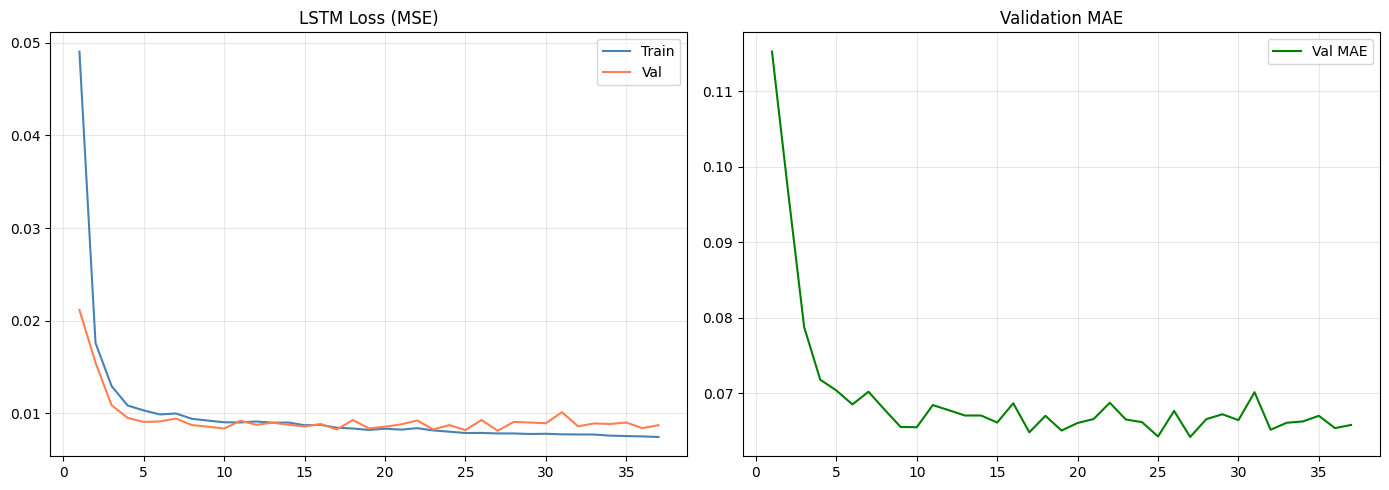

Saved: lstm_training_curves.png

Test MAE (all diseases, all 7 days) : 0.0664
(Target: MAE < 0.05 for risk score [0-1])

Top 10 hardest diseases to forecast (highest MAE):
  Tomato___Leaf_Mold                                      MAE: 0.0871
  Peach___Bacterial_spot                                  MAE: 0.0865
  Tomato___Septoria_leaf_spot                             MAE: 0.0824
  Potato___Early_blight                                   MAE: 0.0820
  Tomato___Early_blight                                   MAE: 0.0819
  Tomato___Bacterial_spot                                 MAE: 0.0777
  Pepper,_bell___Bacterial_spot                           MAE: 0.0776
  Tomato___Target_Spot                                    MAE: 0.0749
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)              MAE: 0.0732
  Tomato___Tomato_mosaic_virus                            MAE: 0.0713

Top 10 easiest diseases to forecast (lowest MAE):
  Tomato___Spider_mites Two-spotted_spider_mite           MAE: 0.0337
  Cherr

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history_lstm['train_loss']) + 1)
 
axes[0].plot(ep, history_lstm['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, history_lstm['val_loss'],   label='Val',   color='coral')
axes[0].set_title('LSTM Loss (MSE)'); axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot(ep, history_lstm['val_mae'], color='green', label='Val MAE')
axes[1].set_title('Validation MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()
print("Saved: lstm_training_curves.png")
model_lstm.load_state_dict(torch.load('best_lstm.pth', map_location=DEVICE))
_, test_mae, test_preds, test_trues = eval_lstm(
    model_lstm, test_loader, criterion_lstm
)
 
print(f"\nTest MAE (all diseases, all 7 days) : {test_mae:.4f}")
print(f"(Target: MAE < 0.05 for risk score [0-1])")
 
# Per-disease MAE
per_disease_mae = {}
for i, disease in enumerate(DISEASE_CLASSES):
    mae = mean_absolute_error(
        test_trues[:, :, i].reshape(-1),
        test_preds[:, :, i].reshape(-1)
    )
    per_disease_mae[disease] = mae
 
print("\nTop 10 hardest diseases to forecast (highest MAE):")
for d, m in sorted(per_disease_mae.items(), key=lambda x: -x[1])[:10]:
    print(f"  {d:<55} MAE: {m:.4f}")
 
print("\nTop 10 easiest diseases to forecast (lowest MAE):")
for d, m in sorted(per_disease_mae.items(), key=lambda x: x[1])[:10]:
    print(f"  {d:<55} MAE: {m:.4f}")



────────────────────────────────────────────────────────────


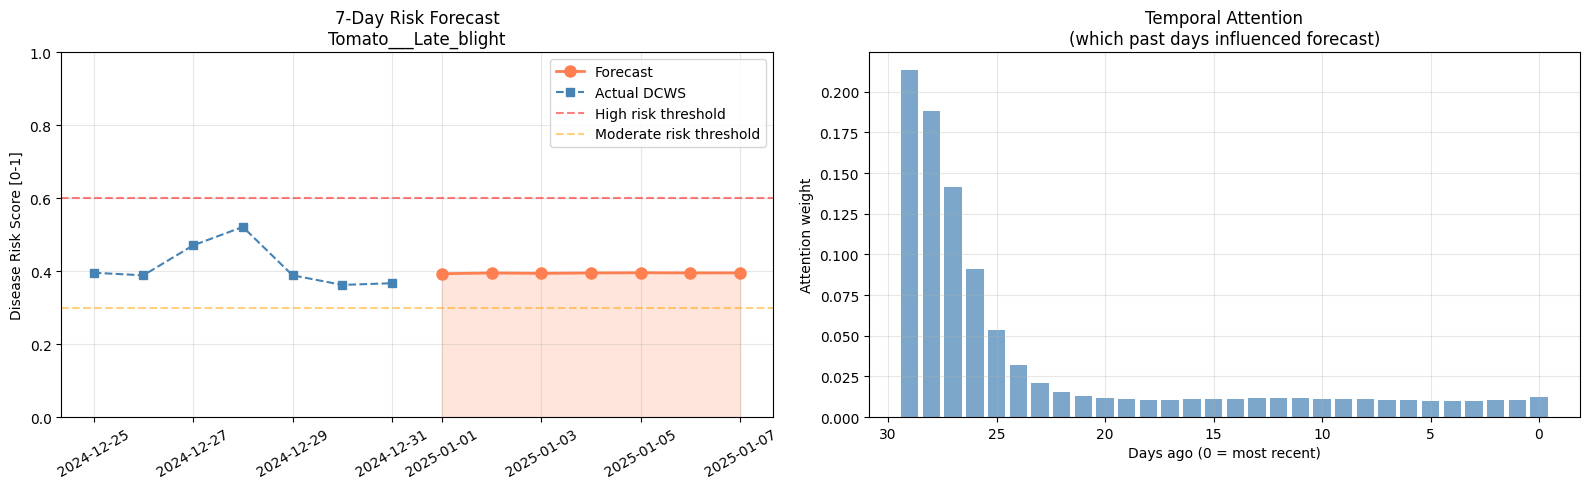

Saved: forecast_Tomato___Late_blight.png

Forecast summary for Tomato___Late_blight:
  Peak risk (next 7 days) : 39.6%  [MODERATE]
  Day 1  Wed 01 Jan  39.3%  ███████
  Day 2  Thu 02 Jan  39.5%  ███████
  Day 3  Fri 03 Jan  39.4%  ███████
  Day 4  Sat 04 Jan  39.5%  ███████
  Day 5  Sun 05 Jan  39.6%  ███████
  Day 6  Mon 06 Jan  39.5%  ███████
  Day 7  Tue 07 Jan  39.5%  ███████

────────────────────────────────────────────────────────────


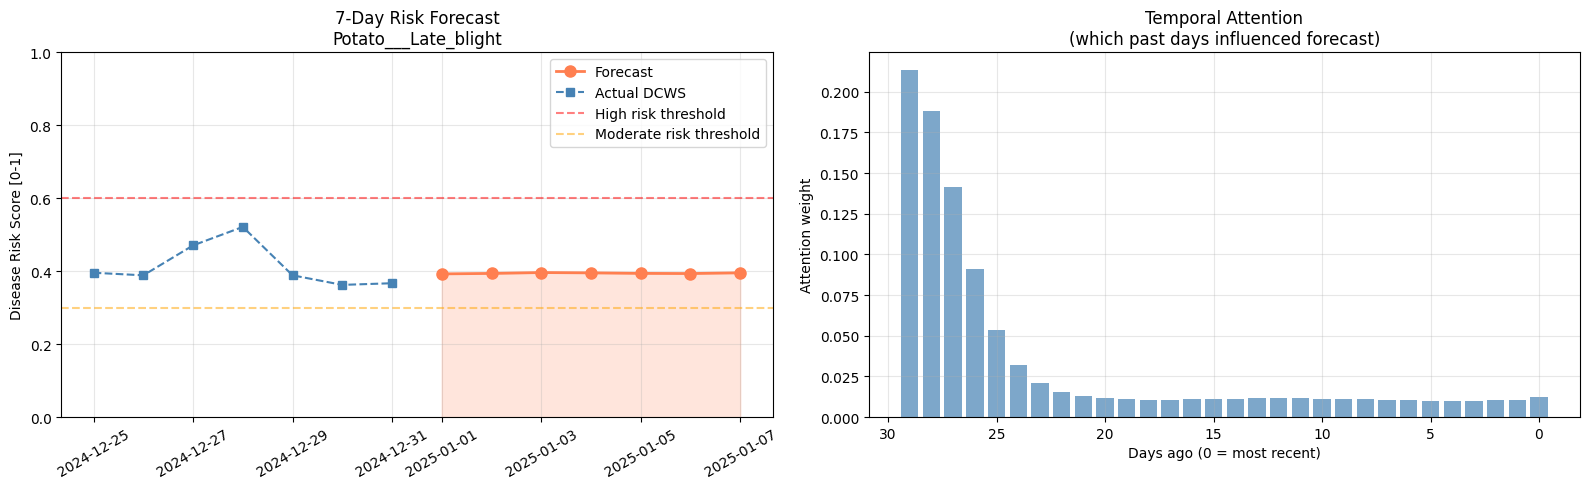

Saved: forecast_Potato___Late_blight.png

Forecast summary for Potato___Late_blight:
  Peak risk (next 7 days) : 39.6%  [MODERATE]
  Day 1  Wed 01 Jan  39.2%  ███████
  Day 2  Thu 02 Jan  39.4%  ███████
  Day 3  Fri 03 Jan  39.6%  ███████
  Day 4  Sat 04 Jan  39.5%  ███████
  Day 5  Sun 05 Jan  39.4%  ███████
  Day 6  Mon 06 Jan  39.3%  ███████
  Day 7  Tue 07 Jan  39.5%  ███████

────────────────────────────────────────────────────────────


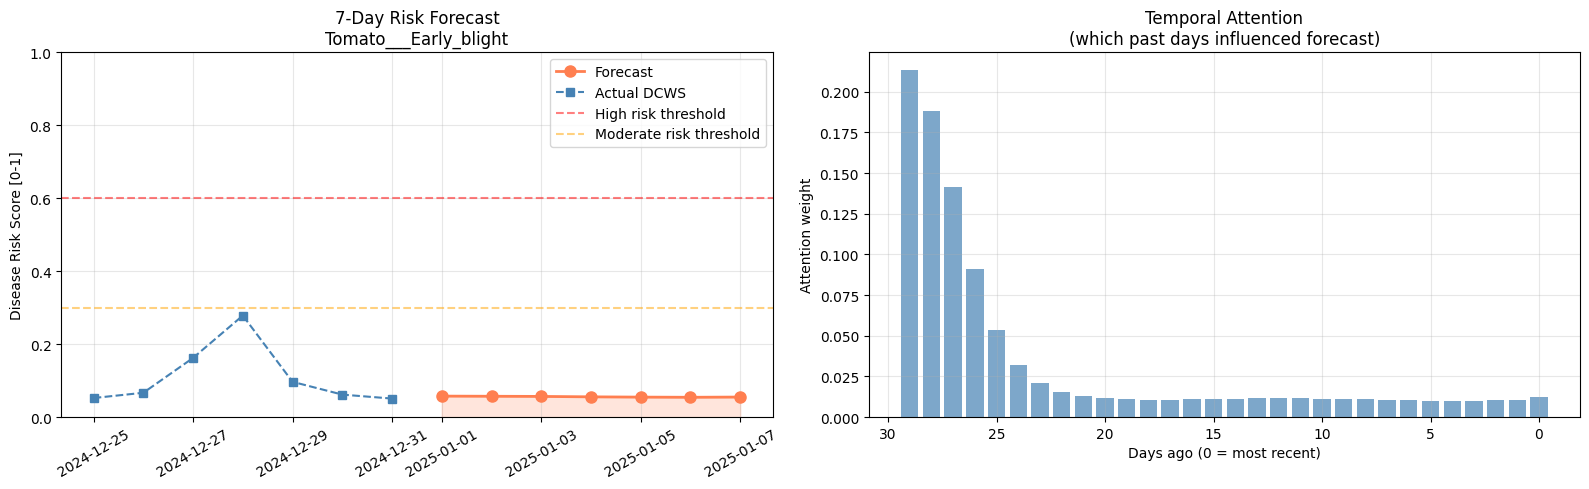

Saved: forecast_Tomato___Early_blight.png

Forecast summary for Tomato___Early_blight:
  Peak risk (next 7 days) : 5.8%  [LOW]
  Day 1  Wed 01 Jan  5.8%  █
  Day 2  Thu 02 Jan  5.7%  █
  Day 3  Fri 03 Jan  5.7%  █
  Day 4  Sat 04 Jan  5.6%  █
  Day 5  Sun 05 Jan  5.5%  █
  Day 6  Mon 06 Jan  5.4%  █
  Day 7  Tue 07 Jan  5.5%  █


In [32]:
def plot_7day_forecast(model, weather_df, dcws_df, disease_name,
                       scaler, n_recent_days=30):
    """
    Takes the most recent 30 days of weather and predicts
    the 7-day disease risk forecast for a given disease.
    """
    model.eval()
    disease_idx = DISEASE_CLASSES.index(disease_name)
 
    # Prepare input: last 30 days
    feat      = weather_df[WEATHER_FEATURES].values[-n_recent_days:].astype(np.float32)
    feat_norm = scaler.transform(feat)
    x_tensor  = torch.tensor(feat_norm).unsqueeze(0).to(DEVICE)
 
    with torch.no_grad():
        pred, _, attn_weights = model(x_tensor)
 
    pred_risk   = pred[0, :, disease_idx].cpu().numpy()       # (7,)
    actual_risk = dcws_df[disease_name].values[-7:] if len(dcws_df) > 7 else None
    attn        = attn_weights[0].cpu().numpy()                # (30,)
 
    # Dates
    last_date    = weather_df.index[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(7)]
    past_dates   = weather_df.index[-30:]
 
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
    # Risk forecast
    axes[0].plot(future_dates, pred_risk, 'o-',
                 color='coral', linewidth=2, markersize=8, label='Forecast')
    if actual_risk is not None and len(actual_risk) == 7:
        actual_dates = weather_df.index[-7:]
        axes[0].plot(actual_dates, actual_risk, 's--',
                     color='steelblue', linewidth=1.5, label='Actual DCWS')
    axes[0].axhline(y=0.6, color='red', linestyle='--',
                    alpha=0.5, label='High risk threshold')
    axes[0].axhline(y=0.3, color='orange', linestyle='--',
                    alpha=0.5, label='Moderate risk threshold')
    axes[0].fill_between(future_dates, pred_risk, alpha=0.2, color='coral')
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f'7-Day Risk Forecast\n{disease_name}')
    axes[0].set_ylabel('Disease Risk Score [0-1]')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    plt.setp(axes[0].get_xticklabels(), rotation=30)
 
    # Attention weights — which past days the model focused on
    axes[1].bar(range(30), attn, color='steelblue', alpha=0.7)
    axes[1].set_title('Temporal Attention\n(which past days influenced forecast)')
    axes[1].set_xlabel('Days ago (0 = most recent)')
    axes[1].set_ylabel('Attention weight')
    axes[1].invert_xaxis()
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    safe_name = disease_name.replace('/', '_').replace(' ', '_')
    plt.savefig(f'forecast_{safe_name}.png', dpi=150)
    plt.show()
    print(f"Saved: forecast_{safe_name}.png")
 
    # Risk level interpretation
    max_risk = pred_risk.max()
    if max_risk > 0.6:
        level = 'HIGH'
    elif max_risk > 0.3:
        level = 'MODERATE'
    else:
        level = 'LOW'
    print(f"\nForecast summary for {disease_name}:")
    print(f"  Peak risk (next 7 days) : {max_risk:.1%}  [{level}]")
    for i, (d, r) in enumerate(zip(future_dates, pred_risk)):
        bar   = '█' * int(r * 20)
        alert = ' ⚠' if r > 0.6 else ''
        print(f"  Day {i+1}  {d.strftime('%a %d %b')}  {r:.1%}  {bar}{alert}")
 
    return pred_risk
 
 
# Plot forecast for key diseases
model_lstm.load_state_dict(torch.load('best_lstm.pth', map_location=DEVICE))
 
for disease in ['Tomato___Late_blight', 'Potato___Late_blight',
                'Tomato___Early_blight']:
    print(f"\n{'─'*60}")
    plot_7day_forecast(
        model_lstm,
        all_weather_dfs[primary_location],
        all_dcws_dfs[primary_location],
        disease,
        train_ds.scaler
    )


In [35]:
def forecast_for_location(lat, lon, location_name,
                           model, scaler, top_n_diseases=5):
    """
    Production function — given GPS coordinates, fetches recent weather
    and returns 7-day disease risk forecast for top N diseases.
    This is called by the FastAPI backend in Increment 4.
    """
    print(f"\nFetching recent weather for {location_name} ({lat}, {lon})...")

    # Fetch last 60 days via NASA POWER directly (Open-Meteo blocked)
    end_date   = '2024-12-31'
    start_date = '2024-11-01'

    raw_df  = fetch_nasa_power(lat, lon, start_date, end_date)
    eng_df  = engineer_features(raw_df)

    if len(eng_df) < LOOKBACK:
        print(f"ERROR: Only {len(eng_df)} days available, need {LOOKBACK}")
        return None

    feat      = eng_df[WEATHER_FEATURES].values[-LOOKBACK:].astype(np.float32)
    feat_norm = scaler.transform(feat)
    x_tensor  = torch.tensor(feat_norm).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred, context, _ = model(x_tensor)

    pred_risk = pred[0].cpu().numpy()    # (7, N_diseases)
    peak_risk = pred_risk.max(axis=0)    # (N_diseases,) — worst day per disease

    # Sort by peak risk
    ranked = sorted(
        zip(DISEASE_CLASSES, peak_risk),
        key=lambda x: -x[1]
    )

    print(f"\n7-Day Disease Risk Forecast — {location_name}")
    print(f"{'─'*60}")
    print(f"{'Disease':<50} {'Peak Risk':>10}  {'Level'}")
    print(f"{'─'*60}")
    for disease, risk in ranked[:top_n_diseases]:
        level = 'HIGH   ⚠' if risk > 0.6 else 'MODERATE' if risk > 0.3 else 'LOW'
        bar   = '█' * int(risk * 20)
        print(f"{disease:<50} {risk:>8.1%}  {level}  {bar}")

    # Return context vector for Increment 3
    return {
        'location'    : location_name,
        'lat'         : lat,
        'lon'         : lon,
        'forecast'    : pred_risk,               # (7, N_diseases) → daily risk
        'peak_risk'   : dict(zip(DISEASE_CLASSES, peak_risk.tolist())),
        'context_vec' : context.cpu().numpy(),   # (1, 256) → Increment 3
        'date'        : datetime.now().strftime('%Y-%m-%d'),
    }


# Run live forecast for Pune
result = forecast_for_location(
    lat=18.5204, lon=73.8567,
    location_name='Pune, Maharashtra',
    model=model_lstm,
    scaler=train_ds.scaler,
    top_n_diseases=10
)


Fetching recent weather for Pune, Maharashtra (18.5204, 73.8567)...
  Fetching from NASA POWER API...
  NASA POWER: 61 days fetched

7-Day Disease Risk Forecast — Pune, Maharashtra
────────────────────────────────────────────────────────────
Disease                                             Peak Risk  Level
────────────────────────────────────────────────────────────
Cherry_(including_sour)___Powdery_mildew              92.4%  HIGH   ⚠  ██████████████████
Squash___Powdery_mildew                               82.9%  HIGH   ⚠  ████████████████
Tomato___Tomato_Yellow_Leaf_Curl_Virus                69.9%  HIGH   ⚠  █████████████
Tomato___Spider_mites Two-spotted_spider_mite         65.5%  HIGH   ⚠  █████████████
Tomato___Tomato_mosaic_virus                          62.8%  HIGH   ⚠  ████████████
Apple___Black_rot                                     60.2%  HIGH   ⚠  ████████████
Orange___Haunglongbing_(Citrus_greening)              55.3%  MODERATE  ███████████
Apple___Apple_scab          

In [36]:
model_lstm.load_state_dict(torch.load('best_lstm.pth', map_location=DEVICE))
torch.save(model_lstm.state_dict(), 'best_lstm.pth')
 
# Save model config (Increment 3 needs to rebuild the architecture)
lstm_config = {
    'input_dim'      : N_FEATURES,
    'hidden_dim'     : 128,
    'num_layers'     : 2,
    'forecast_steps' : FORECAST,
    'n_diseases'     : N_DISEASES,
    'dropout'        : 0.3,
    'lookback'       : LOOKBACK,
    'weather_features': WEATHER_FEATURES,
    'disease_classes' : DISEASE_CLASSES,
    'disease_thresholds': {k: list(v) if v else None
                           for k, v in DISEASE_THRESHOLDS.items()},
    'location_library': LOCATION_LIBRARY,
    'primary_location': primary_location,
}
with open('lstm_config.json', 'w') as f:
    json.dump(lstm_config, f, indent=2)
 
print("\n" + "="*60)
print("INCREMENT 2 COMPLETE")
print("Output files:")
print("  best_lstm.pth          ← LSTM weights")
print("  lstm_config.json       ← model config for Increment 3")
print("  weather_scaler.pkl     ← feature scaler for Increment 3")
print("  weather_features.csv   ← processed weather data")
print("  dcws_scores.csv        ← disease risk scores")
print("  weather_eda.png        ← exploratory plots")
print("  dcws_heatmap.png       ← disease risk heatmap")
print("  lstm_training_curves.png")
print()
print("FEEDS INTO INCREMENT 3:")
print("  context_vec (256-d)    ← weather context for fusion model")
print("  forecast (7, N_dis)    ← 7-day per-disease risk scores")
print("="*60)


INCREMENT 2 COMPLETE
Output files:
  best_lstm.pth          ← LSTM weights
  lstm_config.json       ← model config for Increment 3
  weather_scaler.pkl     ← feature scaler for Increment 3
  weather_features.csv   ← processed weather data
  dcws_scores.csv        ← disease risk scores
  weather_eda.png        ← exploratory plots
  dcws_heatmap.png       ← disease risk heatmap
  lstm_training_curves.png

FEEDS INTO INCREMENT 3:
  context_vec (256-d)    ← weather context for fusion model
  forecast (7, N_dis)    ← 7-day per-disease risk scores
